AND Training Complete
AND Predictions
[0 0 0 1]


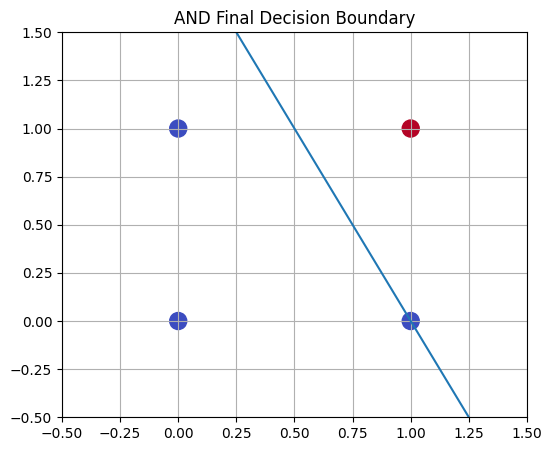

Plots saved in AND_boundaries


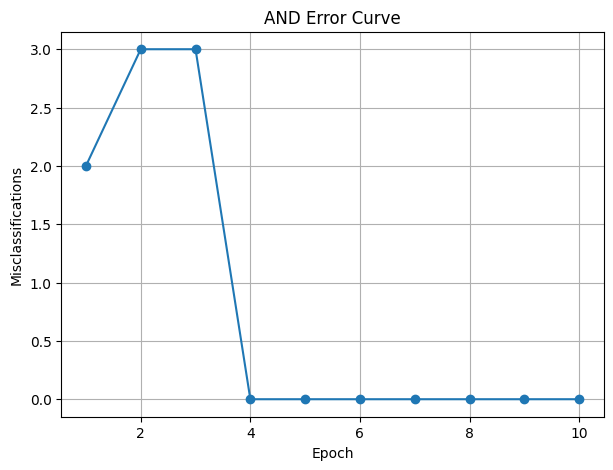

Model saved as and_model.pkl
OR Training Complete
OR Predictions
[0 1 1 1]


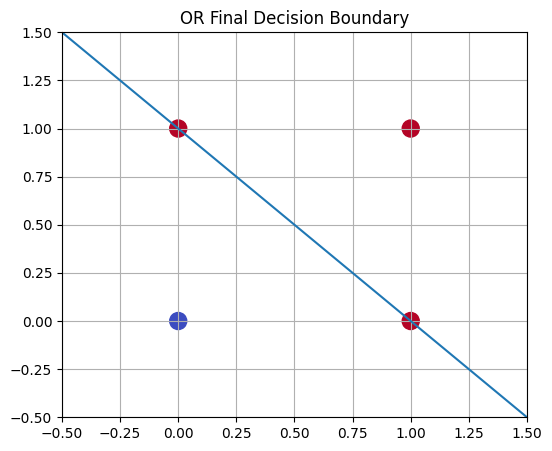

Plots saved in OR_boundaries


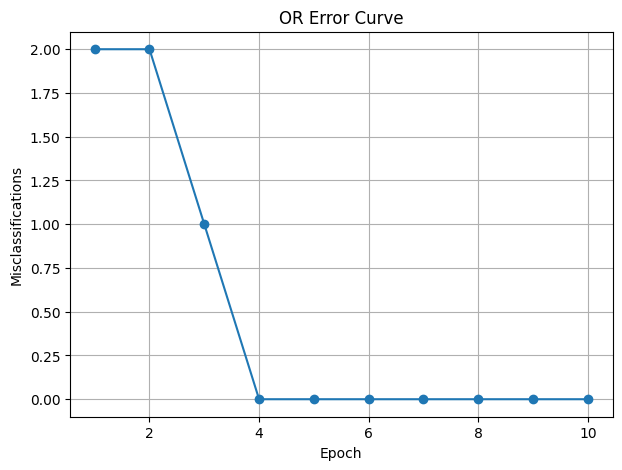

Model saved as or_model.pkl
XOR Training Complete
XOR Predictions
[1 1 0 0]


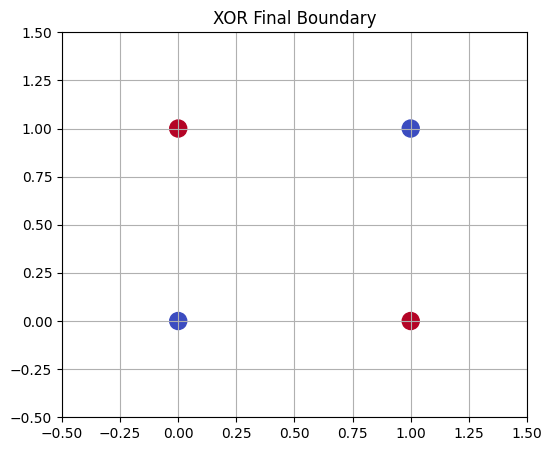

Plots saved in XOR_boundaries


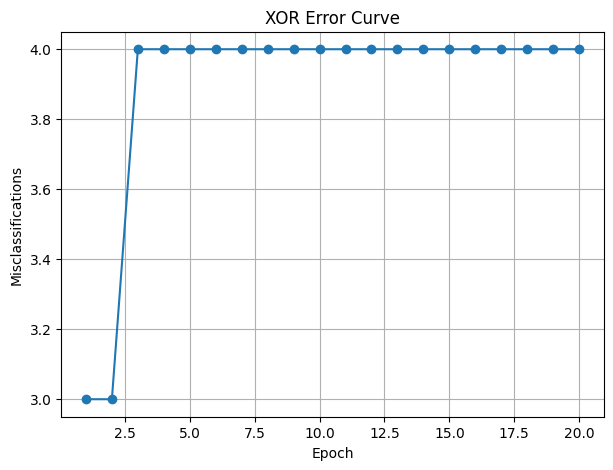


Why XOR Fails?

A Perceptron can only create a single straight-line decision boundary.

AND and OR datasets are linearly separable, so the Perceptron converges.

XOR is NOT linearly separable because no single straight line can separate
the classes correctly.

Therefore, the perceptron keeps making mistakes and fails to converge.

To solve XOR, we need a Multi-Layer Perceptron (MLP) with at least one
hidden layer and nonlinear activation functions.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

class Perceptron:

    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y, dataset_name="dataset"):

        n_features = X.shape[1]

        self.weights = np.zeros(n_features)
        self.bias = 0

        self.errors = []
        self.history = []

        for epoch in range(self.epochs):

            errors = 0

            for xi, target in zip(X, y):

                linear_output = np.dot(xi, self.weights) + self.bias
                prediction = self.activation(linear_output)

                update = self.lr * (target - prediction)

                self.weights += update * xi
                self.bias += update

                errors += int(update != 0)

            self.errors.append(errors)

            self.history.append(
                (
                    self.weights.copy(),
                    self.bias
                )
            )

        print(f"{dataset_name} Training Complete")

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

    def save_model(self, filename="perceptron_model.pkl"):

        model = {
            "weights": self.weights,
            "bias": self.bias
        }

        with open(filename, "wb") as f:
            pickle.dump(model, f)

        print(f"Model saved as {filename}")


def plot_decision_boundary(X, y, weights, bias, title):

    plt.figure(figsize=(6,5))

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap="coolwarm",
        s=150
    )

    x1 = np.linspace(-0.5,1.5,100)

    if weights[1] != 0:
        x2 = -(weights[0]*x1 + bias)/weights[1]
        plt.plot(x1,x2)

    plt.xlim(-0.5,1.5)
    plt.ylim(-0.5,1.5)

    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_epoch_boundaries(model, X, y, name):

    folder = f"{name}_boundaries"

    os.makedirs(folder, exist_ok=True)

    for epoch,(weights,bias) in enumerate(model.history):

        plt.figure(figsize=(6,5))

        plt.scatter(
            X[:,0],
            X[:,1],
            c=y,
            cmap="coolwarm",
            s=150
        )

        x1 = np.linspace(-0.5,1.5,100)

        if weights[1] != 0:
            x2 = -(weights[0]*x1 + bias)/weights[1]
            plt.plot(x1,x2)

        plt.xlim(-0.5,1.5)
        plt.ylim(-0.5,1.5)

        plt.title(f"{name} Epoch {epoch+1}")

        plt.grid(True)

        plt.savefig(f"{folder}/epoch_{epoch+1}.png")
        plt.close()

    print(f"Plots saved in {folder}")


def plot_error_curve(errors, title):

    plt.figure(figsize=(7,5))

    plt.plot(
        range(1,len(errors)+1),
        errors,
        marker="o"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Misclassifications")
    plt.title(title)

    plt.grid(True)
    plt.show()


# ==========================
# AND DATASET
# ==========================

X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

and_model = Perceptron(
    learning_rate=0.1,
    epochs=10
)

and_model.fit(
    X_and,
    y_and,
    "AND"
)

print("AND Predictions")
print(and_model.predict(X_and))

plot_decision_boundary(
    X_and,
    y_and,
    and_model.weights,
    and_model.bias,
    "AND Final Decision Boundary"
)

plot_epoch_boundaries(
    and_model,
    X_and,
    y_and,
    "AND"
)

plot_error_curve(
    and_model.errors,
    "AND Error Curve"
)

and_model.save_model("and_model.pkl")


# ==========================
# OR DATASET
# ==========================

X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_or = np.array([0,1,1,1])

or_model = Perceptron(
    learning_rate=0.1,
    epochs=10
)

or_model.fit(
    X_or,
    y_or,
    "OR"
)

print("OR Predictions")
print(or_model.predict(X_or))

plot_decision_boundary(
    X_or,
    y_or,
    or_model.weights,
    or_model.bias,
    "OR Final Decision Boundary"
)

plot_epoch_boundaries(
    or_model,
    X_or,
    y_or,
    "OR"
)

plot_error_curve(
    or_model.errors,
    "OR Error Curve"
)

or_model.save_model("or_model.pkl")


# ==========================
# XOR DATASET
# ==========================

X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

xor_model = Perceptron(
    learning_rate=0.1,
    epochs=20
)

xor_model.fit(
    X_xor,
    y_xor,
    "XOR"
)

print("XOR Predictions")
print(xor_model.predict(X_xor))

plot_decision_boundary(
    X_xor,
    y_xor,
    xor_model.weights,
    xor_model.bias,
    "XOR Final Boundary"
)

plot_epoch_boundaries(
    xor_model,
    X_xor,
    y_xor,
    "XOR"
)

plot_error_curve(
    xor_model.errors,
    "XOR Error Curve"
)

print("\nWhy XOR Fails?")
print(
"""
A Perceptron can only create a single straight-line decision boundary.

AND and OR datasets are linearly separable, so the Perceptron converges.

XOR is NOT linearly separable because no single straight line can separate
the classes correctly.

Therefore, the perceptron keeps making mistakes and fails to converge.

To solve XOR, we need a Multi-Layer Perceptron (MLP) with at least one
hidden layer and nonlinear activation functions.
"""
)

In [8]:
import pickle
from google.colab import files

model_data = {
    "weights": and_model.weights,
    "bias": and_model.bias
}

with open("and_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

files.download("and_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import pickle
from google.colab import files

model_data = {
    "weights": or_model.weights,
    "bias": or_model.bias
}

with open("or_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

files.download("or_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import pickle
from google.colab import files

model_data = {
    "weights": xor_model.weights,
    "bias": xor_model.bias
}

with open("xor_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

files.download("xor_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>